<a href="https://colab.research.google.com/github/ManoloArriola/black-swan-analysis/blob/main/the_black_swan_in_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Black Swan in Consumption**



##Objective
To apply *Nassim Taleb's* concepts of low-probability, high-impact events through data analysis using Python.

This project aims to:
1. Identify outliers in historical sales data.

2. Differentiate between statistical "noise" and events that change the trend.

3. Create a visual model for decision-making based on uncertainty.

In [ ]:
#For this library we're going to use this libraries to make our analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate 100 days of normal market data
# Most days stay within a predictable range (44-55 units)

np.random.seed(42)
sales_data = np.random.randint(45, 55, size=100)

# 2. Injecting "Black Swans"
# Unexpected, extreme events (pikes and crashes)
sales_data[25] = 150  # Massive spike
sales_data[70] = 5    # Sudden crash
sales_data[85] = 130  # Another outlier

# 3. Create DataFrame
df = pd.DataFrame({'Day':range(1,101),'Sales':sales_data})

# 4. Preliminary check
print("Market Overview (first 5 days):")
print(df.head())
print(sales_data)
print(pd.DataFrame(sales_data))
#

Market Overview (first 5 days):
   Day  Sales
0    1     51
1    2     48
2    3     52
3    4     49
4    5     51
[ 51  48  52  49  51  54  47  51  52  49  48  52  52  47  50  49  46  52
  50  46  49  45  54  50  53 150  54  47  51  48  53  47  49  47  51  49
  53  51  46  48  53  46  54  53  54  49  46  48  51  52  47  45  48  46
  52  48  46  50  50  54  48  50  46  54  46  54  48  52  51  53   5  49
  46  49  52  54  53  53  45  53  51  53  52  45  52 130  47  45  52  47
  47  45  49  54  51  54  53  51  53  52]
     0
0   51
1   48
2   52
3   49
4   51
..  ..
95  54
96  53
97  51
98  53
99  52

[100 rows x 1 columns]


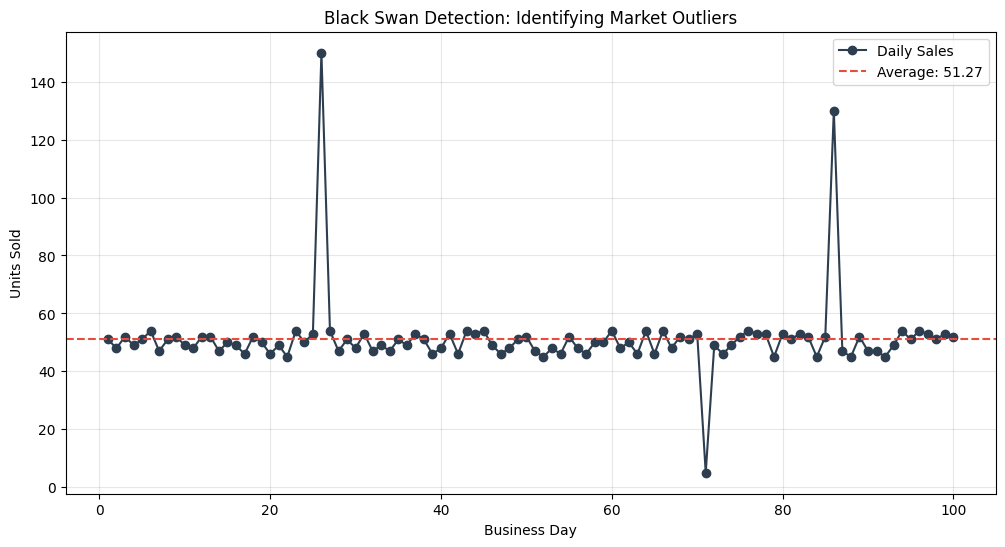

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Day'], df['Sales'], marker='o', color='#2c3e50', label='Daily Sales')

# Calculate the mean (The "Mediocristan" expectation)
mean_val = df['Sales'].mean()
plt.axhline(y=mean_val, color='#e74c3c', linestyle='--', label=f'Average: {mean_val:.2f}')

plt.title('Black Swan Detection: Identifying Market Outliers')
plt.xlabel('Business Day')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

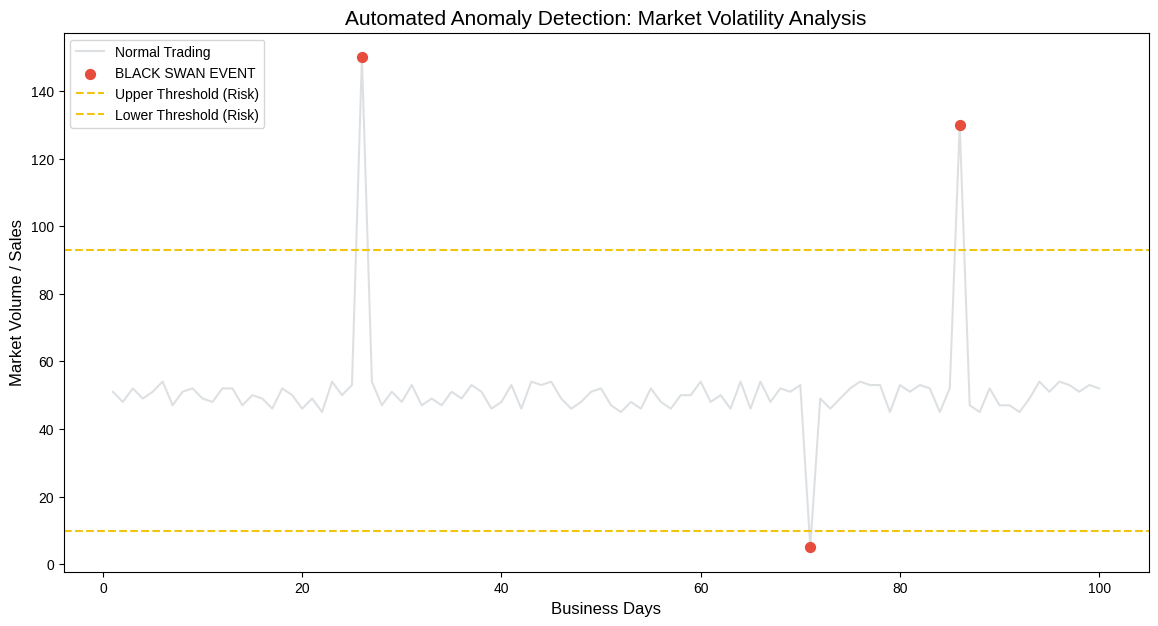

In [ ]:
# Re-calculating the variables needed for the plot
mean_val = df['Sales'].mean()
std_dev = df['Sales'].std()

# Define thresholds (3-sigma rule)
upper_threshold = mean_val + (3 * std_dev)
lower_threshold = mean_val - (3 * std_dev)

# Identify the Black Swans
cisnes_negros = df[(df['Sales'] > upper_threshold) | (df['Sales'] < lower_threshold)]

# Step 4: Intelligent Highlighting of Black Swans
plt.figure(figsize=(14, 7))

# Plot the regular data
plt.plot(df['Day'], df['Sales'], color='#bdc3c7', alpha=0.5, label='Normal Trading')

# Identify and plot Black Swans with a different color/marker
# We use the same 'cisnes_negros' filter we talked about before
plt.scatter(cisnes_negros['Day'], cisnes_negros['Sales'], color='#e74c3c', s=50, label='BLACK SWAN EVENT', zorder=5)

# Add Threshold lines (The boundaries of "Normal")
plt.axhline(y=upper_threshold, color='#f1c40f', linestyle='--', label='Upper Threshold (Risk)')
plt.axhline(y=lower_threshold, color='#f1c40f', linestyle='--', label='Lower Threshold (Risk)')

# Professional Formatting
plt.title('Automated Anomaly Detection: Market Volatility Analysis', fontsize=15)
plt.xlabel('Business Days', fontsize=12)
plt.ylabel('Market Volume / Sales', fontsize=12)
plt.legend()
plt.style.use('seaborn-v0_8-whitegrid') # This makes it look modern
plt.show()